In [1]:
# 05 – Complaint Analysis


'''This notebook combines the predicted review categories with ratings and dates to answer 
the complaint questions (Q3–Q5), explain recent rating drops, and support the final recommendations (Q8). 
Because the classifier is about 56% accurate, findings focus on large differences, 
are rechecked using only confident predictions, and are verified by reading actual reviews.'''

'This notebook combines the predicted review categories with ratings and dates to answer \nthe complaint questions (Q3–Q5), explain recent rating drops, and support the final recommendations (Q8). \nBecause the classifier is about 56% accurate, findings focus on large differences, \nare rechecked using only confident predictions, and are verified by reading actual reviews.'

In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/processed/reviews.db")

def q(sql):
    return pd.read_sql(sql, conn)  # run a SQL query and return a table


In [3]:
# the most common complaints per app (Q3)
def complaint_share(min_conf=0.0):
    return q(f"""
    WITH complaints AS (                              -- step 1: only complaint reviews
        SELECT r.app_name, c.category
        FROM reviews r
        JOIN review_categories c ON r.reviewId = c.reviewId
        WHERE c.category NOT IN ('Praise', 'Other / off-topic')
          AND c.confidence >= {min_conf}
    )
    SELECT app_name, category,
           COUNT(*) AS reviews,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY app_name), 1) AS pct   -- step 2: share within each app
    FROM complaints
    GROUP BY app_name, category
    """)

shares = complaint_share()

# reshape into one row per category and one column per app, easier to compare
shares.pivot(index="category", columns="app_name", values="pct")

app_name,Credit Karma,Monarch Money,Rocket Money,YNAB
category,,,,
"Account, login & support",21.5,5.4,11.0,3.4
Ads & upselling,37.3,1.4,2.7,1.4
Bank connection / sync,7.0,23.1,20.4,15.2
Bugs & performance,4.9,12.2,9.1,5.6
Missing features,13.9,21.0,6.0,14.3
Pricing & subscription,6.0,26.0,41.6,30.0
Usability & design,9.4,10.9,9.3,30.2


In [4]:
# which complaints come with the lowest ratings (Q4)
q("""
SELECT c.category,
       COUNT(*) AS reviews,
       ROUND(AVG(r.score), 2) AS avg_rating
FROM reviews r
JOIN review_categories c ON r.reviewId = c.reviewId
GROUP BY c.category
ORDER BY avg_rating
""")

,category,reviews,avg_rating
0,"Account, login & support",3913,1.73
1,Bank connection / sync,3320,2.36
2,Ads & upselling,5117,2.74
3,Missing features,2840,2.76
4,Usability & design,2587,2.76
5,Bugs & performance,1725,2.99
6,Other / off-topic,5932,3.10
7,Pricing & subscription,5354,3.16
8,Praise,17711,4.71


<Axes: title={'center': 'Share of complaints by category, per quarter'}, xlabel='quarter', ylabel='% of complaints'>

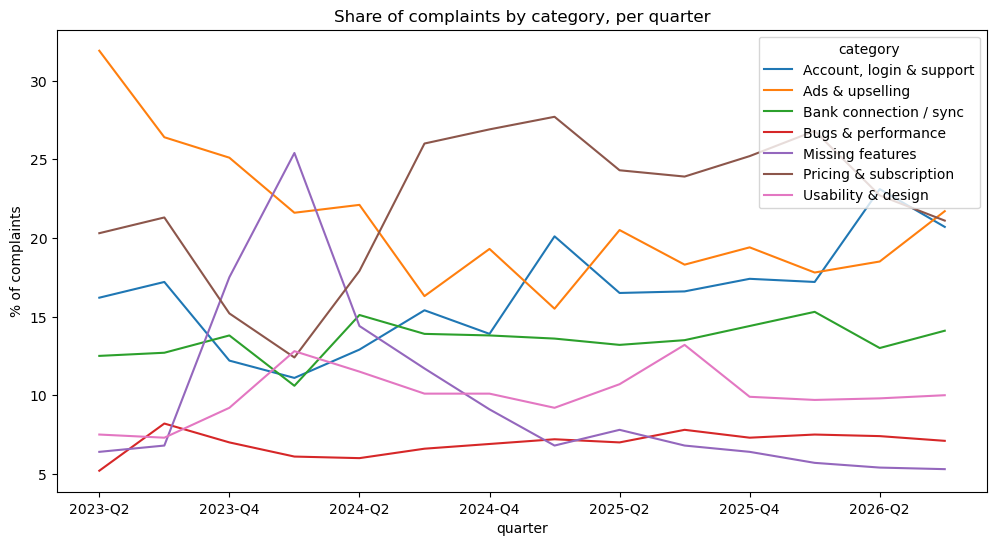

In [5]:
# how complaints change over time (Q5)
trend = q("""
WITH quarterly AS (
    SELECT substr(r.month, 1, 4) || '-Q' || ((CAST(substr(r.month, 6, 2) AS INTEGER) + 2) / 3) AS quarter,  -- e.g. "2024-Q1"
           c.category
    FROM reviews r
    JOIN review_categories c ON r.reviewId = c.reviewId
    WHERE c.category NOT IN ('Praise', 'Other / off-topic')
)
SELECT quarter, category,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY quarter), 1) AS pct
FROM quarterly
GROUP BY quarter, category
ORDER BY quarter
""")

chart = trend.pivot(index="quarter", columns="category", values="pct")
chart.plot(figsize=(12, 6), title="Share of complaints by category, per quarter", ylabel="% of complaints")

In [6]:
# what changed for Rocket Money and YNAB
q("""
WITH periods AS (
    SELECT r.app_name, c.category,
           CASE WHEN r.month BETWEEN '2025-01' AND '2025-06' THEN 'a_early_2025'
                WHEN r.month >= '2026-01' THEN 'b_2026' END AS period
    FROM reviews r
    JOIN review_categories c ON r.reviewId = c.reviewId
    WHERE r.app_name IN ('Rocket Money', 'YNAB')
)
SELECT app_name, category, period,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY app_name, period), 1) AS pct_of_reviews
FROM periods
WHERE period IS NOT NULL                        -- leave out months in neither period
GROUP BY app_name, category, period
ORDER BY app_name, category, period
""").pivot_table(index=["app_name", "category"], columns="period", values="pct_of_reviews")

period                                 a_early_2025  b_2026
app_name     category                                      
Rocket Money Account, login & support           4.6     7.5
             Ads & upselling                    1.3     1.7
             Bank connection / sync             8.0    10.7
             Bugs & performance                 4.3     4.6
             Missing features                   2.8     2.4
             Other / off-topic                  4.0     3.9
             Praise                            51.4    42.4
             Pricing & subscription            19.2    21.3
             Usability & design                 4.4     5.4
YNAB         Account, login & support           2.7     4.2
             Ads & upselling                    0.4     1.0
             Bank connection / sync            10.6    10.8
             Bugs & performance                 1.6     3.8
             Missing features                  10.6     4.2
             Other / off-topic                  1.6     1.4
             Praise                            40.4    32.5
             Pricing & subscription            16.5    21.3
             Usability & design                15.7    20.6

In [8]:
# robustness check with confident predictions only
# same as Cell 2, but only predictions the model was at least 50% sure about
confident = complaint_share(min_conf=0.5)
confident.pivot(index="category", columns="app_name", values="pct")

app_name,Credit Karma,Monarch Money,Rocket Money,YNAB
category,,,,
"Account, login & support",58.5,NaN,34.1,4.5
Ads & upselling,34.0,NaN,NaN,NaN
Bank connection / sync,2.7,23.8,28.5,22.7
Pricing & subscription,4.8,76.2,37.4,72.7


In [12]:
# # read real reviews behind a finding
# change the app, category, and date to check any finding you want
pd.set_option("display.max_colwidth", None)  # show full review text
q("""
SELECT r.month, r.score, r.content
FROM reviews r
JOIN review_categories c ON r.reviewId = c.reviewId
WHERE r.app_name = 'YNAB'
  AND c.category = 'Usability & design'
  AND r.month >= '2026-01'
ORDER BY RANDOM()
LIMIT 10
""")

,month,score,content
0,2026-01,5,YNAB has made it easier to see my spending within each budget category. Highly flexible customization of budget layout. Super helpful library of videos to understand the app and how to think about money management differently.
1,2026-08,3,"while I like YNAB and feel like it is a good investment, I am not a fan of the latest update. Font is smaller, now I have to use my reading glasses to see the app, didn't have to before. there's way too much info, it feels cluttered. I don't like how you cannot easily see the details on a saved transaction when you go to edit. you have to click ""see more"" to see details. this adds no benefit to the app. the one thing I like is the option to easily see uncleared transactions."
2,2026-07,1,absolutely hate the new update. takes so much longer to input and clear transactions.
3,2026-07,1,ANOTHER update brings in a new UI just for the sake of it to justify some product manager's jobs. You've now added more taps required to get to flags and clear transactions. WHY. Stop messing with the UI!!!
4,2026-08,1,Recent app development has made much harder to use and doesn't seem to always follow the YNAB method.
5,2026-04,5,"Overall I highly recommend this to anyone looking to improve their budgeting! I moved to YNAB after Simple Bank closed, so it's been quite a while now. It did take some doing to get set up, but after that YNAB worked really well. I use the Home tab: I pinned credit cards there, so now it's fewer taps to record those payments. Requests: Spending tab needs filtering features to be useful, and the start of the month is clumsy as transactions clear from end of previous month."
6,2026-06,5,The best budget app ever!!!
7,2026-06,1,I've been using this app for 4 years and it was so helpful. However recently there have been many really bad design choices. The UI is incredibly hard to use now. They fired key members of their marketing team. I will be finding a new platform going forward. YNAB is now too much of an uncaring corporation.
8,2026-02,1,"From 5 star to 1 star. What used to be a slim, fast, and agile app has become the typical ""bloat"" of busy body programmers. Last update added an unneeded home page that clutters and slows things down. Startup, entries, everything USED to be instantaneous. Now? A delay with every button press! Maddening! STOP PROGRAMMING TO BE BUSY BODIES!! Slim it down and make it better, not worse. UPDATE: Less bloat would help the delays. Stop making the program worse."
9,2026-03,1,not great. it's a strange way to set a budget and it's overall very clunky. you assign payments that have already been made to categories and then it takes that money from what is in your accounts even though it's already been paid. too much work and too much nonsense


In [11]:
# verify: are Rocket Money's 2026 login/account complaints real?
pd.set_option("display.max_colwidth", None)  # show full review text
q("""
SELECT r.month, r.score, r.content
FROM reviews r
JOIN review_categories c ON r.reviewId = c.reviewId
WHERE r.app_name = 'Rocket Money'
  AND c.category = 'Account, login & support'
  AND r.month >= '2026-01'
ORDER BY RANDOM()
LIMIT 10
""")

,month,score,content
0,2026-08,1,when I created and account it recognized my email and said I have an account already and took me thru tedious process and when I tried to sign in using the same email it didn't recognized my email what a waste of my time!
1,2026-04,2,"I had this app before. I tried to load it and use it again, but my phone number has changed and I can't put the stupid code in."
2,2026-06,5,Best place to see all my finances and credit report in one app so I don't have to log into everything separately to get the overview
3,2026-02,1,App won't allow me to create an account
4,2026-03,4,"nice app but PayPal account IS A CHECKING ACCOUNT so I have no choice, seeing I cannot open an account WITHOUT A CHECKING ACCOUNT, but to delete your app."
5,2026-04,1,can no longer log in. screen keeps looping
6,2026-03,1,"Not trustworthy. Somehow I ended up with two different accounts, both using the same login ID and password and can't log in to either. Cancelled and uninstalled."
7,2026-09,1,"When I try to log in, I get am error that says there is no account associated to email. when I attempt to create an account, I get an error saying that there is an existing account associated with that email. so which is it????"
8,2026-05,1,"I got a new phone with a new number and I downloaded this app again. I logged in and it wanted to send me a verification code to my old number. No options, no way to change to email instead or to enter my new number. NO OPTIONS. except uninstall"
9,2026-05,2,"app won't open anymore, even with reinstalling"


In [13]:
## Key findings

1. **Each app has a distinct main complaint.** Credit Karma: ads and upselling (37% of complaints). Monarch Money: pricing (26%) and bank sync (23%). Rocket Money: pricing (42%, partly inflated by misclassified subscription-detection complaints) and bank sync (20%). YNAB: usability (30%) and pricing (30%).
2. **Account and login problems are the most damaging.** These reviews average 1.73 stars, followed by bank sync at 2.36. Pricing complaints are milder (3.16), often from users who like the app but find it expensive.
3. **Pricing became the biggest complaint overall.** Its share of complaints rose from about 12% in early 2024 to 22–27% since. Ads complaints fell from 32% to about 20%. Missing-feature complaints spiked to 25% in early 2024, during the Mint transition.
4. **YNAB's 2026 rating drop is driven by redesigns.** Usability complaints rose from 16% to 21% of reviews and praise fell from 40% to 33%. In a sample of these reviews, 7 of 10 complained about recent updates adding screens and steps.
5. **Rocket Money's 2026 decline is about reliability.** Account/login complaints rose from 4.6% to 7.5% and sync from 8.0% to 10.7%. In a sample, 8 of 10 described accounts not being recognized or verification codes going to old phone numbers.

## Recommendations

1. **For a new budgeting app:** compete on reliable bank connections and login, the problems behind the lowest ratings across all four apps.
2. **Credit Karma:** reduce ads and product offers, its top complaint and the main reason former Mint users rated it 1.30 stars.
3. **Monarch Money:** show pricing before sign-up, since users are frustrated by paywalls that appear after onboarding.
4. **Rocket Money:** fix account recognition at sign-up and login, and let users update their phone number for verification.
5. **YNAB:** stop adding steps and screens to core workflows like entering and clearing transactions.

**Limitations:** the classifier is about 56% accurate, so findings focus on large differences and were verified by reading samples of real reviews. The complaint trend chart combines all four apps, so shifts partly reflect which app was being reviewed.

SyntaxError: invalid decimal literal (3074194878.py, line 5)

In [ ]:
conn.close()